In [1]:
import re
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve

In [2]:
dataset = "moderation_decisions.csv"
df = pd.read_csv(Path.cwd() / dataset).drop("id", axis=1)
df

,type,title,body,decision
0,post,gif test,"*hello* **world**. type away your post, in <u>...",approved
1,comment,NaN,night,approved
2,comment,NaN,good night everyone,approved
3,post,Mid sems se boht fat rahi hai,Kal se exams hai aur kuch padhai nahi hui hai 🥶,approved
4,comment,NaN,yelo gyaan chodu aa gaye,flagged
...,...,...,...,...
1036,comment,NaN,That's cap,approved
1037,comment,NaN,stfu you little swiftie cunt,flagged
1038,comment,NaN,"hi, I'm the problem, it's me",approved
1039,comment,NaN,Spill the tea dude,approved


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   type      1041 non-null   str  
 1   title     177 non-null    str  
 2   body      1041 non-null   str  
 3   decision  1041 non-null   str  
dtypes: str(4)
memory usage: 32.7 KB


In [4]:
df.describe()

,type,title,body,decision
count,1041,177,1041,1041
unique,2,164,989,2
top,comment,Regarding the akshat consipracy,"*hello* **world**. type away your post, in <u>...",approved
freq,864,5,16,807


### Missing values

In [5]:
df.isnull().sum() / df.shape[0]

type        0.000000
title       0.829971
body        0.000000
decision    0.000000
dtype: float64

In [6]:
df["type"].value_counts() / df.shape[0]

type
comment    0.829971
post       0.170029
Name: count, dtype: float64

~83% of rows don't have a title, implying they are all comments. We can verify this using the unique value counts.

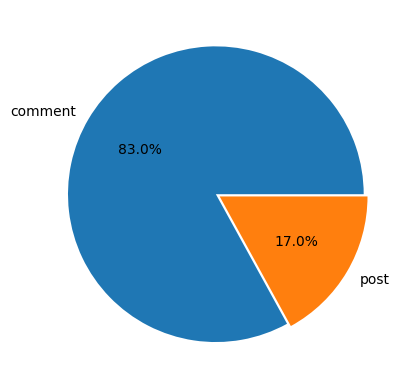

In [7]:
counts = df["type"].value_counts()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", explode=[0, 0.03])
plt.show()

### Class Distribution

<Axes: >

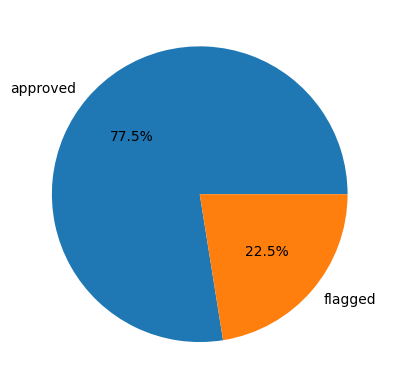

In [8]:
df["decision"].value_counts().plot.pie(autopct="%1.1f%%")

We can see that there is a class imbalance in the target variable.

### TF-IDF Approach

We'll use a hybrid approach consisting of both word (captures meaning) and character (captures variations) n-grams.

In [9]:
def clean(s: str):
    return re.sub(r"[^a-z\s]", "", s.strip().lower())


df["text"] = (df["title"].fillna("") + " " + df["body"]).apply(clean)

X = df["text"]
y = df["decision"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=33
)

In [10]:
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2), min_df=3, max_df=0.9, max_features=8000, sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    max_features=18000,
    sublinear_tf=True,
)

tfidf_union = FeatureUnion(
    [
        ("word_tfidf", word_tfidf),
        ("char_tfidf", char_tfidf),
    ]
)

model = Pipeline(
    [
        ("features", tfidf_union),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)),
    ]
)

In [11]:
model.fit(X_train, y_train)

/home/shravan/code/everynyan-moderation-service/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('word_tfidf', ...), ('char_tfidf', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [12]:
y_probs = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs, pos_label="flagged")
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.39695488326744693
Best F1: 0.6538461533507766


In [13]:
def predict_toxic(text: str, threshold: float = 0.396):
    text = clean(text)
    prob = model.predict_proba([text])[0][1]  # probability for flagged class
    return "flagged" if prob > threshold else "approved"

y_pred = ([predict_toxic(t) for t in X_test])
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    approved       0.91      0.86      0.89       162
     flagged       0.60      0.72      0.65        47

    accuracy                           0.83       209
   macro avg       0.76      0.79      0.77       209
weighted avg       0.84      0.83      0.83       209



In [14]:
clf = model.named_steps["clf"]
features = model.named_steps["features"]

word_features = features.transformer_list[0][1].get_feature_names_out()
char_features = features.transformer_list[1][1].get_feature_names_out()

all_features = np.concatenate([word_features, char_features])
weights = clf.coef_[0]

top_toxic = np.argsort(weights)[-20:]

print("Top toxic features:")
for i in top_toxic:
    print(all_features[i], weights[i])

Top toxic features:
 ga 0.8525765698663927
ts  0.8582600557600636
 ch 0.8671088947285868
tu 0.8682683074647898
 lod 0.86983351645454
lod 0.86983351645454
ne 0.8793387916953743
my 0.8828969664469255
chu 0.9061994997482895
chutiye 0.9149119721549079
 chu 0.9294757259837867
gand 0.9356936314598528
chodu 0.969072910991667
niggers 0.9692282110570742
 ki 1.0108515191660221
lodu 1.063078507582639
kys 1.0740770019596433
lode 1.1996996143172476
gay 1.3319462439033962
bkl 1.5500571564789074
